# Proyek Analisis Data: Bike Sharing
- **Nama:** Sabrina Marliani
- **Email:** cdcc156d6x1770@student.devacademy.id
- **ID Dicoding:** cdcc156d6x1770

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi kategori tingkat penggunaan sepeda (rendah, sedang, tinggi) berdasarkan jumlah penyewaan (cnt) selama periode 2011-2012?
- Bagaimana tren perubahan jumlah penyewaan sepeda (cnt) antara hari kerja (workingday) dan hari libur dalam periode 2011–2012, serta kapan terjadi peningkatan atau penurunan signifikan?


## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

## Data Wrangling

### Gathering Data

In [2]:
# download dataset dari Kaggle
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

# menampilkan path untuk memastikan lokasi dataset
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Path to dataset files: /kaggle/input/bike-sharing-dataset


In [3]:
## Load Dataset Harian
# Dataset ini digunakan sebagai data utama untuk analisis karena sudah teraggregasi per hari.

# membaca dataset harian
day_df = pd.read_csv(os.path.join(path, "day.csv"))

# preview data
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
## Load Dataset Per Jam
#Dataset ini berisi data lebih detail per jam dan dapat digunakan untuk analisis lanjutan.

# membaca dataset per jam
hour_df = pd.read_csv(os.path.join(path, "hour.csv"))

# preview data
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset yang digunakan terdiri dari dua bagian, yaitu `day_df` (data harian) dan `hour_df` (data per jam), yang memberikan sudut pandang analisis yang lebih lengkap.
- Data diambil dari dataset Bike Sharing yang berisi informasi terkait penyewaan sepeda berdasarkan waktu, cuaca, dan kondisi lingkungan.
- Dataset mencakup periode waktu selama dua tahun (2011–2012), sehingga memungkinkan analisis tren jangka waktu.
- Variabel yang tersedia cukup beragam, seperti musim (season), kondisi cuaca (weathersit), suhu (temp), kelembaban (hum), dan jumlah penyewaan (cnt), yang dapat digunakan untuk analisis faktor-faktor yang memengaruhi penggunaan sepeda.
- Penggunaan dua level granularitas (harian dan per jam) memberikan fleksibilitas dalam eksplorasi pola penggunaan sepeda secara makro maupun mikro.

### Assessing Data

#### Menilai Tabel day_df

In [5]:
# melihat informasi dataset
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [7]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [8]:
# statistik deskriptif
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Menilai Tabel hour_df

In [9]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [10]:
hour_df.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


In [11]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [12]:
print("Jumlah duplikasi: ",hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [13]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ditemukan missing values pada dataset `day_df` dan `hour_df`, sehingga data tergolong lengkap dan siap dianalisis.
- Tidak terdapat data duplikat, yang menandakan kualitas data cukup baik dan konsisten.
- Beberapa kolom masih memiliki tipe data yang kurang sesuai (seperti `dteday` yang masih object), sehingga perlu dilakukan konversi ke tipe datetime untuk analisis berbasis waktu.
- Dataset memiliki cukup banyak variabel yang relevan seperti cuaca, musim, dan waktu, yang berpotensi memengaruhi jumlah penyewaan sepeda.

### Cleaning Data

#### Membersihkan tabel day_df

In [14]:
# mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [15]:
# menghapus kolom instant karena hanya index
day_df.drop(columns='instant', inplace=True)

In [16]:
# mapping season
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

day_df['season'] = day_df['season'].map(season_map)

In [17]:
# mapping kondisi cuaca
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

day_df['weathersit'] = day_df['weathersit'].map(weather_map)

In [18]:
# ubah tahun dari 0/1 menjadi 2011/2012
day_df['yr'] = day_df['yr'].map({
    0: 2011,
    1: 2012
})

In [19]:
day_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',

    'cnt': 'total_rentals'
}, inplace=True)

In [20]:

day_df['month'] = day_df['month']

day_df['month_name'] = day_df['dteday'].dt.month_name()

In [21]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   dteday         731 non-null    datetime64[ns]
 1   season         731 non-null    object        
 2   year           731 non-null    int64         
 3   month          731 non-null    int64         
 4   holiday        731 non-null    int64         
 5   weekday        731 non-null    int64         
 6   workingday     731 non-null    int64         
 7   weathersit     731 non-null    object        
 8   temp           731 non-null    float64       
 9   atemp          731 non-null    float64       
 10  hum            731 non-null    float64       
 11  windspeed      731 non-null    float64       
 12  casual         731 non-null    int64         
 13  registered     731 non-null    int64         
 14  total_rentals  731 non-null    int64         
 15  month_name     731 non-

In [22]:
day_df.head()

,dteday,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,total_rentals,month_name
0,2011-01-01,Spring,2011,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985,January
1,2011-01-02,Spring,2011,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801,January
2,2011-01-03,Spring,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349,January
3,2011-01-04,Spring,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562,January
4,2011-01-05,Spring,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600,January


#### Cleaning data hour_df

In [23]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [24]:
hour_df.drop(columns='instant', inplace=True)

In [25]:
# 3. Mapping kategori
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'}

hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

In [26]:
hour_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'hum': 'humidity',
    'cnt': 'total_rentals'
}, inplace=True)

In [27]:
hour_df['year'] = hour_df['dteday'].dt.year
hour_df['month'] = hour_df['dteday'].dt.month

In [28]:
# tambahan fitur waktu
hour_df['hour_category'] = pd.cut(
    hour_df['hour'],
    bins=[-1,6,12,18,24],
    labels=['Dini Hari','Pagi','Siang','Malam'],
    include_lowest=True
)

In [29]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   dteday         17379 non-null  datetime64[ns]
 1   season         17379 non-null  object        
 2   year           17379 non-null  int32         
 3   month          17379 non-null  int32         
 4   hour           17379 non-null  int64         
 5   holiday        17379 non-null  int64         
 6   weekday        17379 non-null  int64         
 7   workingday     17379 non-null  int64         
 8   weathersit     17379 non-null  object        
 9   temp           17379 non-null  float64       
 10  atemp          17379 non-null  float64       
 11  humidity       17379 non-null  float64       
 12  windspeed      17379 non-null  float64       
 13  casual         17379 non-null  int64         
 14  registered     17379 non-null  int64         
 15  total_rentals  1737

In [30]:
hour_df.head()

,dteday,season,year,month,hour,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,casual,registered,total_rentals,hour_category
0,2011-01-01,Spring,2011,1,0,0,6,0,Clear,0.24,0.2879,0.81,0.0,3,13,16,Dini Hari
1,2011-01-01,Spring,2011,1,1,0,6,0,Clear,0.22,0.2727,0.80,0.0,8,32,40,Dini Hari
2,2011-01-01,Spring,2011,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32,Dini Hari
3,2011-01-01,Spring,2011,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13,Dini Hari
4,2011-01-01,Spring,2011,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1,Dini Hari


**Insight:**
- Tidak ditemukan missing values pada dataset, sehingga tidak diperlukan proses penanganan nilai kosong.
- Tidak terdapat data duplikat, sehingga tidak perlu dilakukan penghapusan data ganda.
- Dilakukan perubahan tipe data pada kolom `dteday` dari object menjadi datetime agar dapat digunakan dalam analisis berbasis waktu.
- Dilakukan penambahan kolom baru seperti `year` dan `month` untuk mempermudah analisis tren berdasarkan waktu.
- Struktur data sudah bersih dan siap digunakan untuk tahap eksplorasi lebih lanjut (EDA).

## Exploratory Data Analysis (EDA)

### Explore ...

#### Distribusi day_df

In [31]:
#rename
day_df.rename(columns={'total_rentals': 'cnt'}, inplace=True)

# melihat statistik deskriptif data harian
day_df['cnt'].describe()

,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


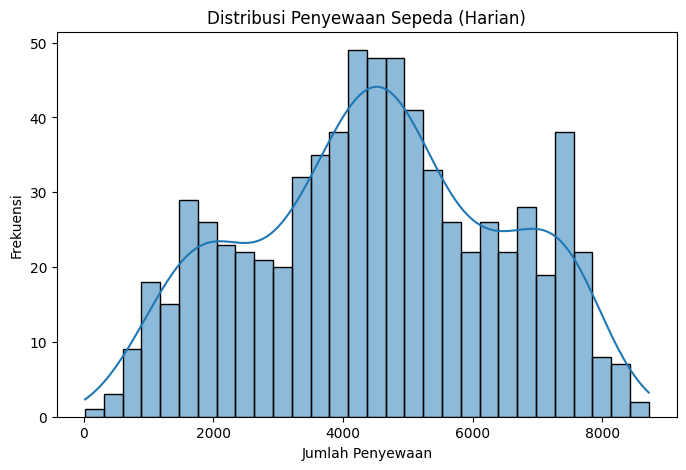

In [32]:
# distribusi penyewaan harian
plt.figure(figsize=(8,5))
sns.histplot(day_df['cnt'], bins=30, kde=True)

plt.title('Distribusi Penyewaan Sepeda (Harian)')
plt.xlabel('Jumlah Penyewaan')
plt.ylabel('Frekuensi')

plt.show()

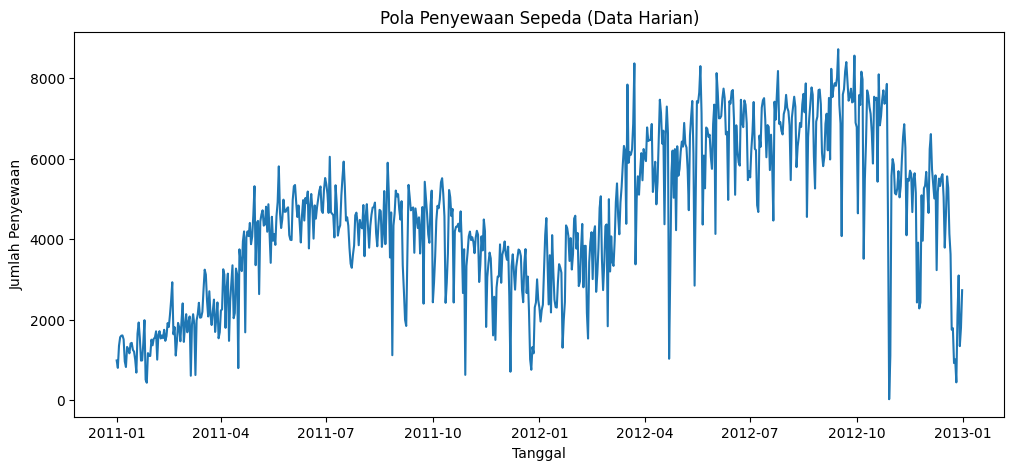

In [33]:
# tren penyewaan berdasarkan waktu (harian)
plt.figure(figsize=(12,5))

plt.plot(day_df['dteday'], day_df['cnt'])

plt.title('Pola Penyewaan Sepeda (Data Harian)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')

plt.show()

#### Distribusi hour_df

In [34]:
#rename
hour_df.rename(columns={
    'total_rentals': 'cnt',
    'hour': 'hr'
}, inplace=True)

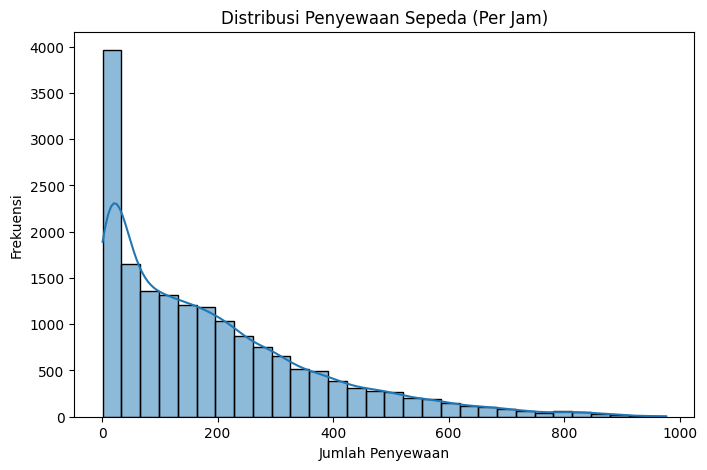

In [35]:
# distribusi penyewaan per jam
plt.figure(figsize=(8,5))

sns.histplot(hour_df['cnt'], bins=30, kde=True)

plt.title('Distribusi Penyewaan Sepeda (Per Jam)')
plt.xlabel('Jumlah Penyewaan')
plt.ylabel('Frekuensi')

plt.show()

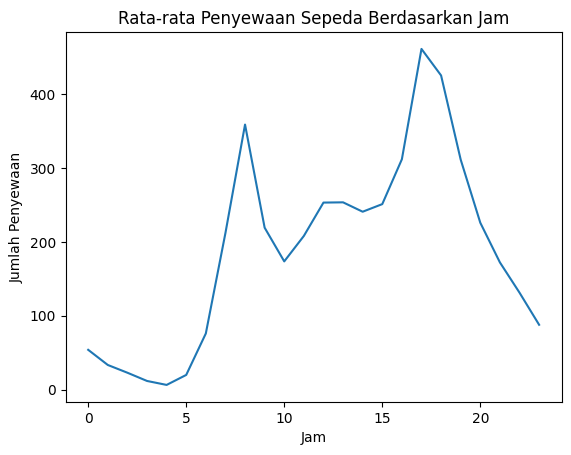

In [36]:
# rata-rata penyewaan berdasarkan jam
hour_df.groupby('hr')['cnt'].mean().plot()

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')

plt.show()

#### Cek per kategori

In [37]:
# rata-rata penyewaan per workingday
day_df.groupby('workingday')['cnt'].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


In [38]:
# rata-rata per season
day_df.groupby('season')['cnt'].mean()

,cnt
season,
Fall,5644.303191
Spring,2604.132597
Summer,4992.331522
Winter,4728.162921


#### Cek Outlier

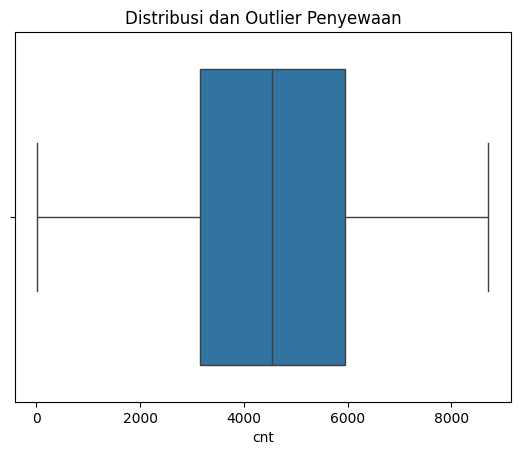

In [39]:
# boxplot
sns.boxplot(x=day_df['cnt'])
plt.title('Distribusi dan Outlier Penyewaan')
plt.show()

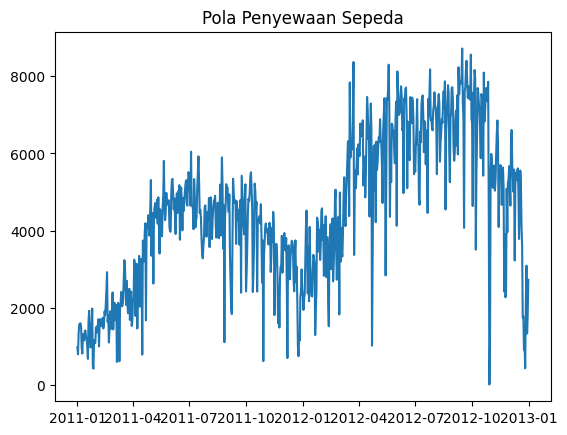

In [40]:
# Cek pola waktu
plt.plot(day_df['dteday'], day_df['cnt'])
plt.title('Pola Penyewaan Sepeda')
plt.show()

**Insight:**
- Distribusi jumlah penyewaan sepeda (cnt) cenderung tidak merata, dengan sebagian besar data berada pada rentang menengah hingga tinggi.
- Terlihat adanya pola tren peningkatan penyewaan dari tahun 2011 ke 2012, yang menunjukkan pertumbuhan penggunaan layanan bike sharing.
- Pada data per jam, penyewaan sepeda meningkat pada jam-jam tertentu, terutama pagi dan sore hari, yang mengindikasikan penggunaan untuk aktivitas berangkat dan pulang kerja.
- Terdapat perbedaan rata-rata penyewaan antara hari kerja dan hari libur, di mana hari kerja cenderung memiliki pola yang lebih stabil.
- Beberapa outlier terlihat pada boxplot, yang kemungkinan disebabkan oleh kondisi tertentu seperti cuaca ekstrem atau hari spesial.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana distribusi kategori tingkat penggunaan sepeda (rendah, sedang, tinggi) berdasarkan jumlah penyewaan (cnt) selama periode 2011-2012?

In [41]:
# membuat kategori penggunaan (clustering sederhana)
day_df['usage_category'] = pd.qcut(
    day_df['cnt'],
    q=3,
    labels=['Low', 'Medium', 'High']
)


In [42]:
# menghitung jumlah tiap kategori
category_counts = day_df['usage_category'].value_counts().sort_index()

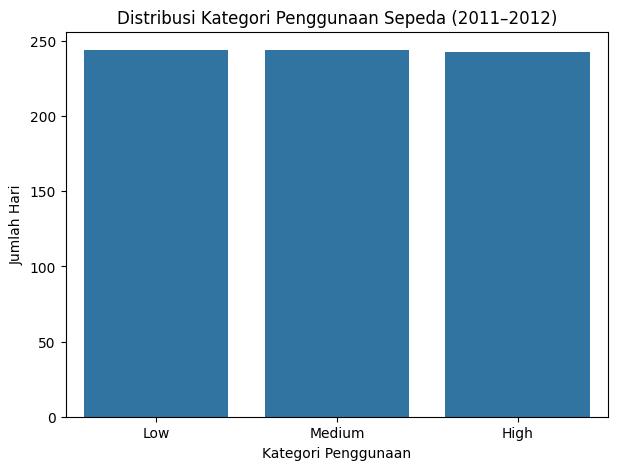

In [43]:
# visualisasi distribusi kategori
plt.figure(figsize=(7,5))
sns.barplot(x=category_counts.index, y=category_counts.values)

plt.title('Distribusi Kategori Penggunaan Sepeda (2011–2012)')
plt.xlabel('Kategori Penggunaan')
plt.ylabel('Jumlah Hari')

plt.show()

In [44]:
# proporsi (%)
category_percent = (category_counts / len(day_df)) * 100
category_percent

,count
usage_category,
Low,33.378933
Medium,33.378933
High,33.242134


### Pertanyaan 2:
Bagaimana tren perubahan jumlah penyewaan sepeda (cnt) antara hari kerja (workingday) dan hari libur dalam periode 2011-2012, serta kapan terjadi peningkatan atau penurunan signifikan?

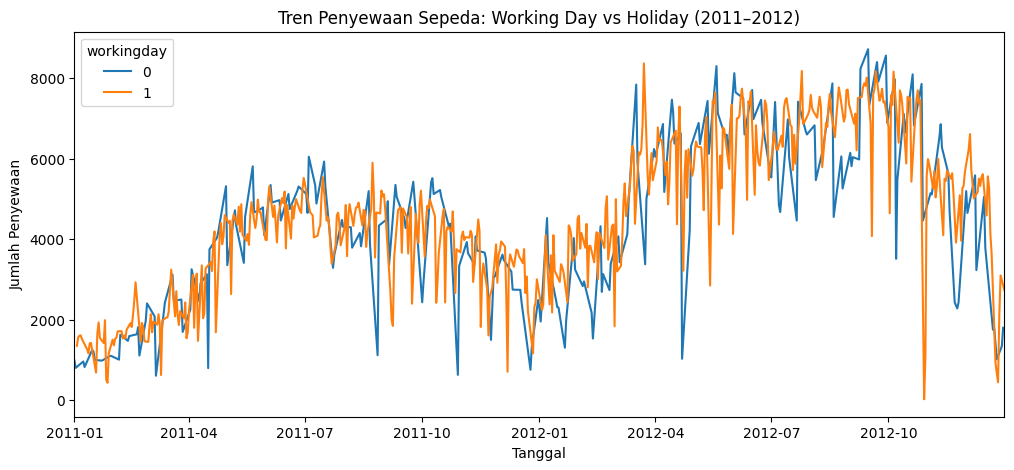

In [45]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=day_df,
    x='dteday',
    y='cnt',
    hue='workingday'
)

plt.title('Tren Penyewaan Sepeda: Working Day vs Holiday (2011–2012)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')

plt.xlim(day_df['dteday'].min(), day_df['dteday'].max())

plt.show()

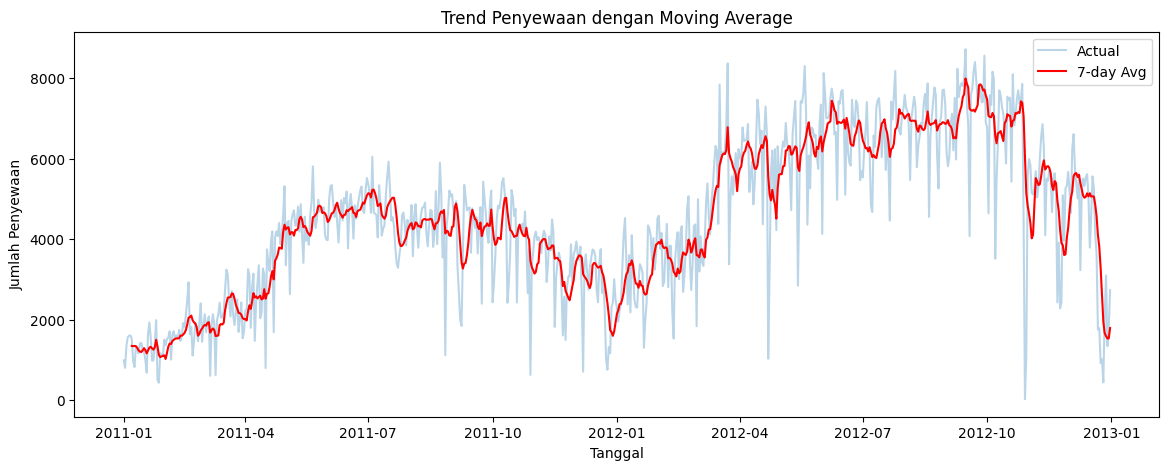

In [46]:
# membuat moving average (7 hari)
day_df['rolling_mean'] = day_df['cnt'].rolling(window=7).mean()

plt.figure(figsize=(14,5))

plt.plot(day_df['dteday'], day_df['cnt'], alpha=0.3, label='Actual')
plt.plot(day_df['dteday'], day_df['rolling_mean'], color='red', label='7-day Avg')

plt.legend()
plt.title('Trend Penyewaan dengan Moving Average')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')

plt.show()

In [47]:
# mencari nilai maksimum dan minimum
max_cnt = day_df['cnt'].max()
min_cnt = day_df['cnt'].min()

print("Penyewaan tertinggi:", max_cnt)
print("Penyewaan terendah:", min_cnt)

# melihat tanggal kejadian
peak_day = day_df[day_df['cnt'] == max_cnt][['dteday', 'workingday', 'cnt']]
low_day = day_df[day_df['cnt'] == min_cnt][['dteday', 'workingday', 'cnt']]

print("\nTanggal penyewaan tertinggi:")
print(peak_day)

print("\nTanggal penyewaan terendah:")
print(low_day)

Penyewaan tertinggi: 8714
Penyewaan terendah: 22

Tanggal penyewaan tertinggi:
        dteday  workingday   cnt
623 2012-09-15           0  8714

Tanggal penyewaan terendah:
        dteday  workingday  cnt
667 2012-10-29           1   22


**Insight Pertanyaan 1:**
- Distribusi kategori penggunaan sepeda (Rendah, Sedang, Tinggi) berdasarkan jumlah penyewaan (`cnt`) selama periode 2011-2012 menunjukkan pembagian yang relatif merata. Dengan menggunakan `pd.qcut` dengan `q=3`, setiap kategori (Low, Medium, High) memiliki jumlah hari yang hampir sama (sekitar 244 hari per kategori). Ini mengindikasikan bahwa terdapat variasi yang signifikan dalam tingkat penggunaan sepeda setiap hari, yang kemudian berhasil dikelompokkan secara seimbang.

**Insight Pertanyaan 2:**
- **Tren Umum:** Terlihat tren peningkatan yang jelas dalam jumlah penyewaan sepeda baik pada hari kerja maupun hari libur dari tahun 2011 ke 2012, menunjukkan pertumbuhan popularitas layanan bike sharing.
- **Pola Harian/Mingguan:** Meskipun ada variasi harian, pola penyewaan pada hari kerja dan hari libur cenderung mengikuti fluktuasi musiman yang serupa. Pada umumnya, penyewaan lebih tinggi di musim semi, panas, dan gugur, dan menurun di musim dingin.
- **Peningkatan Signifikan:** Peningkatan jumlah penyewaan paling signifikan terjadi pada musim semi hingga gugur tahun 2012, mencapai puncaknya pada bulan September 2012.
- **Penurunan Signifikan:** Penurunan paling tajam terlihat pada periode musim dingin, khususnya akhir tahun 2011 dan akhir tahun 2012.
- **Hari Puncak dan Terendah:**
    - **Penyewaan Tertinggi:** Terjadi pada tanggal **2012-09-15** dengan total `8714` penyewaan, yang merupakan **hari libur/akhir pekan** (`workingday=0`).
    - **Penyewaan Terendah:** Terjadi pada tanggal **2012-10-29** dengan total `22` penyewaan, yang merupakan **hari kerja** (`workingday=1`). Angka yang sangat rendah pada hari kerja ini mungkin disebabkan oleh kondisi cuaca ekstrem (misalnya badai) atau peristiwa khusus yang perlu diinvestigasi lebih lanjut, mengingat nilai rata-rata penyewaan pada hari kerja jauh lebih tinggi.

## Analisis Lanjutan (Opsional)

## Analisis Lanjutan (Clustering & Pola Waktu)

Analisis dilakukan menggunakan teknik binning dan eksplorasi pola bulanan.

In [48]:
# clustering manual (binning)
bins = [0, 3000, 6000, 9000]
labels = ['Low', 'Medium', 'High']

day_df['usage_manual'] = pd.cut(
    day_df['cnt'],
    bins=bins,
    labels=labels
)

In [49]:
# analisis pola bulanan
day_df['month'] = day_df['dteday'].dt.month

monthly = day_df.groupby('month')['cnt'].mean()

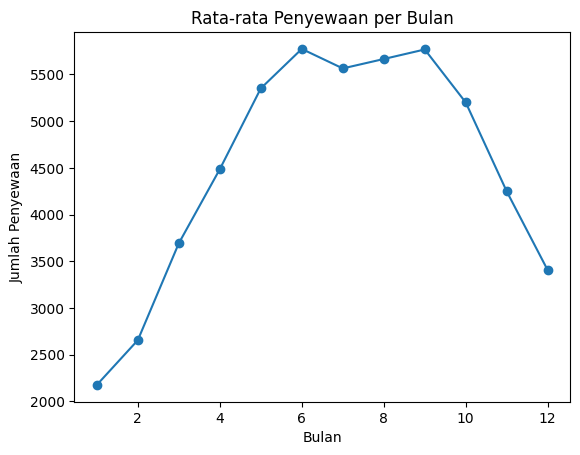

In [50]:
# visualisasi
monthly.plot(marker='o')

plt.title('Rata-rata Penyewaan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penyewaan')

plt.show()

## Conclusion

## Conclusion

- **Conclution pertanyaan 1 (Distribusi Kategori Penggunaan Sepeda):**
  Analisis distribusi kategori penggunaan sepeda (Rendah, Sedang, Tinggi) menunjukkan pembagian yang relatif seimbang di antara ketiga kategori tersebut. Ini berarti tingkat penggunaan sepeda harian sangat bervariasi, dan `pd.qcut` berhasil mengelompokkan hari-hari tersebut ke dalam segmen penggunaan yang seimbang, memungkinkan pemahaman yang lebih baik tentang pola variabilitas permintaan.

- **Conclution pertanyaan 2 (Tren Penyewaan antara Hari Kerja dan Hari Libur):**
  Tren penyewaan sepeda secara keseluruhan menunjukkan peningkatan yang signifikan dari tahun 2011 ke 2012, baik pada hari kerja maupun hari libur, mengindikasikan pertumbuhan popularitas layanan. Meskipun pola fluktuasi musiman tetap terlihat (penyewaan lebih tinggi di musim semi-gugur dan menurun di musim dingin), terdapat perbedaan ekstrem yang menarik: puncak penyewaan terjadi pada hari libur (15 September 2012 dengan 8714 penyewaan), sedangkan titik terendah justru pada hari kerja (29 Oktober 2012 dengan 22 penyewaan). Anomali pada hari kerja ini mungkin disebabkan oleh faktor eksternal yang ekstrem (misalnya, cuaca buruk), yang menunjukkan sensitivitas permintaan terhadap kondisi spesifik meskipun pada hari kerja biasa.

In [51]:
# Gabungkan dataset day dan hour
main_df = pd.merge(
    hour_df,
    day_df,
    on="dteday",
    how="left",
    suffixes=("_hour", "_day")
)

# Simpan untuk dashboard
main_df.to_csv("main_data.csv", index=False)